# 04 · Random forest: `src/ensemble/_random_forest.py`

Tests for `RandomForest`: bagged `DecisionTree`s with random feature subsets, majority voting, the out-of-bag (OOB) score and averaged feature importances.

| Data | Source | What it tests |
|---|---|---|
| Noisy moons (2-D) | generated | an ensemble generalises better than a single tree |
| Breast Cancer, Wine | scikit-learn, bundled | OOB vs test accuracy, vs scikit-learn's `RandomForestClassifier` |
| `make_classification` with 5 informative of 20 features | generated | importances find the informative features |
| Spambase (4 601 × 57) | **online** (UCI id 94) | real-world performance |

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, ensemble as skens
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.ensemble._random_forest import RandomForest
from src.trees._decision_tree import DecisionTree

checks = Checks("04 random forest")
acc = lambda model, X, y: float(np.mean(model.predict(X) == y))

## 1. Structure and determinism

In [2]:
X_bc, y_bc = datasets.load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.3, random_state=SEED, stratify=y_bc)

rf = RandomForest(n_estimators=25, max_depth=6, random_state=SEED)
checks.check("fit() returns self", rf.fit(Xtr, ytr) is rf)
checks.check("trees_ has n_estimators trees", len(rf.trees_) == 25 and all(isinstance(t, DecisionTree) for t in rf.trees_))
checks.check("classes_ are the sorted labels", np.array_equal(rf.classes_, [0, 1]))
checks.check("every tree respects max_depth", max(t.get_depth() for t in rf.trees_) <= 6)

same = RandomForest(n_estimators=25, max_depth=6, random_state=SEED).fit(Xtr, ytr)
checks.check("same random_state → identical predictions", np.array_equal(rf.predict(Xte), same.predict(Xte)))
tree_preds = np.array([t.predict(Xte) for t in rf.trees_])
checks.check("trees differ from each other (bootstrap + feature subsets)",
             len({p.tobytes() for p in tree_preds}) > 1)

vote = (tree_preds.mean(axis=0) > 0.5).astype(int)   # odd number of trees → no ties
checks.check("predict() is the majority vote of the trees", np.array_equal(vote, rf.predict(Xte)))

imp = rf.feature_importances_
checks.close("feature_importances_ sum to 1", imp.sum(), 1.0)
checks.close("feature_importances_ = mean of the trees' importances",
             imp, np.mean([t.feature_importances_ for t in rf.trees_], axis=0), atol=1e-9)

✅ fit() returns self
✅ trees_ has n_estimators trees
✅ classes_ are the sorted labels
✅ every tree respects max_depth
✅ same random_state → identical predictions
✅ trees differ from each other (bootstrap + feature subsets)
✅ predict() is the majority vote of the trees
✅ feature_importances_ sum to 1  (max |Δ| = 0.00e+00)
✅ feature_importances_ = mean of the trees' importances  (max |Δ| = 0.00e+00)


True

### No bootstrap and all features → every tree is the same tree

With `bootstrap=False` and `max_features=None`, all trees see the same data and every feature, so the forest must reproduce a single `DecisionTree` exactly.

In [3]:
plain = RandomForest(n_estimators=5, max_depth=4, bootstrap=False, max_features=None, random_state=0).fit(Xtr, ytr)
single = DecisionTree(max_depth=4).fit(Xtr, ytr)
checks.check("bagging off + all features == single tree", np.array_equal(plain.predict(Xte), single.predict(Xte)))

✅ bagging off + all features == single tree


True

## 2. An ensemble beats a single tree on noisy data

A deep tree overfits the noise in the moons data. Averaging many de-correlated trees should reduce that variance. We average over five data seeds to keep the comparison fair.

mean test accuracy  single tree: 0.829 | forest: 0.843
✅ forest beats a single deep tree on average  (0.843 > 0.829)


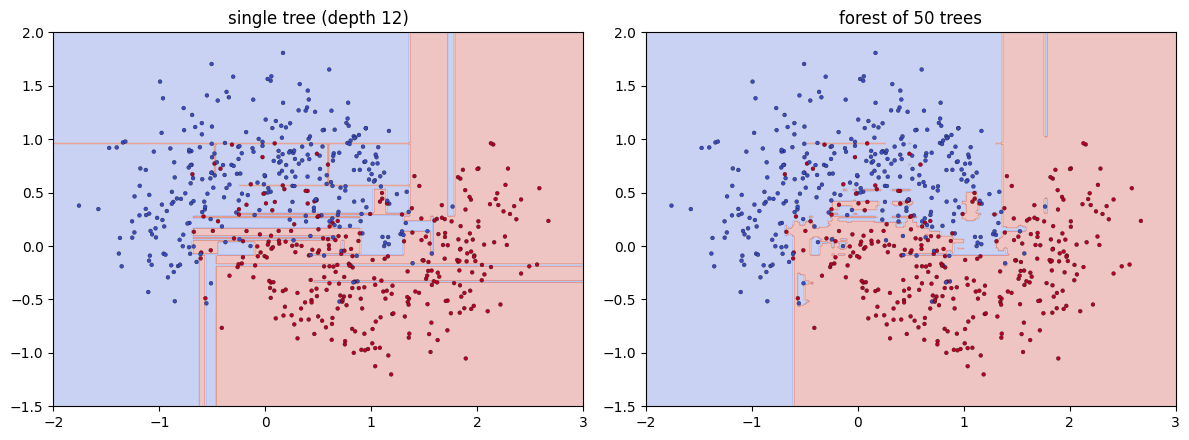

In [4]:
tree_scores, forest_scores = [], []
for seed in range(5):
    X, y = datasets.make_moons(n_samples=600, noise=0.35, random_state=seed)
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.5, random_state=seed)
    tree_scores.append(acc(DecisionTree(max_depth=12).fit(Xa, ya), Xb, yb))
    forest_scores.append(acc(RandomForest(n_estimators=50, max_depth=12, max_features=None, random_state=seed).fit(Xa, ya), Xb, yb))
print(f"mean test accuracy  single tree: {np.mean(tree_scores):.3f} | forest: {np.mean(forest_scores):.3f}")
checks.check("forest beats a single deep tree on average", np.mean(forest_scores) > np.mean(tree_scores),
             f"{np.mean(forest_scores):.3f} > {np.mean(tree_scores):.3f}")

X, y = datasets.make_moons(n_samples=600, noise=0.35, random_state=0)
models = {"single tree (depth 12)": DecisionTree(max_depth=12).fit(X, y),
          "forest of 50 trees": RandomForest(n_estimators=50, max_depth=12, max_features=None, random_state=0).fit(X, y)}
xx, yy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.5, 2, 250))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, m) in zip(axes, models.items()):
    ax.contourf(xx, yy, m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape), alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8, edgecolor="k", linewidth=0.2)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 3. Out-of-bag estimate and number of trees

The OOB score evaluates each sample only with the trees that did not see it during training, so it should track the held-out test accuracy closely.

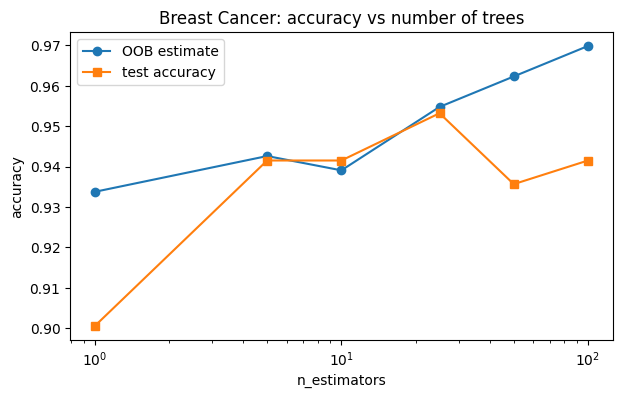

✅ OOB ≈ test accuracy (100 trees)  (0.0283 ≤ 0.05)
✅ 100 trees ≥ 1 tree on test  (0.942 vs 0.901)
✅ oob_score_ is in [0, 1]


True

In [5]:
n_list = [1, 5, 10, 25, 50, 100]
oob, test = [], []
for n in n_list:
    m = RandomForest(n_estimators=n, max_depth=8, oob_score=True, random_state=SEED).fit(Xtr, ytr)
    oob.append(m.oob_score_); test.append(acc(m, Xte, yte))

plt.figure(figsize=(7, 4))
plt.plot(n_list, oob, "o-", label="OOB estimate"); plt.plot(n_list, test, "s-", label="test accuracy")
plt.xscale("log"); plt.xlabel("n_estimators"); plt.ylabel("accuracy"); plt.title("Breast Cancer: accuracy vs number of trees"); plt.legend()
plt.show()

checks.at_most("OOB ≈ test accuracy (100 trees)", abs(oob[-1] - test[-1]), 0.05)
checks.check("100 trees ≥ 1 tree on test", test[-1] >= test[0], f"{test[-1]:.3f} vs {test[0]:.3f}")
checks.check("oob_score_ is in [0, 1]", all(0.0 <= v <= 1.0 for v in oob))

## 4. Comparison with scikit-learn

In [6]:
rows = []
for name, loader in [("Breast Cancer", datasets.load_breast_cancer), ("Wine", datasets.load_wine), ("Iris", datasets.load_iris)]:
    X, y = loader(return_X_y=True)
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    with timed(f"{name}: our forest (100 trees)"):
        ours = RandomForest(n_estimators=100, max_depth=8, random_state=SEED).fit(Xa, ya)
    ref = skens.RandomForestClassifier(n_estimators=100, max_depth=8, criterion="entropy", random_state=SEED).fit(Xa, ya)
    rows.append({"dataset": name, "ours": acc(ours, Xb, yb), "sklearn": ref.score(Xb, yb),
                 "importance corr.": np.corrcoef(ours.feature_importances_, ref.feature_importances_)[0, 1]})
    checks.at_most(f"{name}: |ours − sklearn| test accuracy", abs(rows[-1]["ours"] - rows[-1]["sklearn"]), 0.04)
    checks.at_least(f"{name}: importances correlate with sklearn", rows[-1]["importance corr."], 0.8)
display(pd.DataFrame(rows).round(3))

⏱️ Breast Cancer: our forest (100 trees): 0.40s
✅ Breast Cancer: |ours − sklearn| test accuracy  (0.0000 ≤ 0.04)
✅ Breast Cancer: importances correlate with sklearn  (0.9069 ≥ 0.8)


⏱️ Wine: our forest (100 trees): 0.15s
✅ Wine: |ours − sklearn| test accuracy  (0.0185 ≤ 0.04)
✅ Wine: importances correlate with sklearn  (0.9508 ≥ 0.8)
⏱️ Iris: our forest (100 trees): 0.08s


✅ Iris: |ours − sklearn| test accuracy  (0.0222 ≤ 0.04)
✅ Iris: importances correlate with sklearn  (0.9980 ≥ 0.8)


,dataset,ours,sklearn,importance corr.
0,Breast Cancer,0.942,0.942,0.907
1,Wine,0.981,1.000,0.951
2,Iris,0.911,0.889,0.998


## 5. Feature importances find the informative features

`make_classification` with `shuffle=False` puts the 5 informative features in columns 0–4. The other 15 columns are noise.

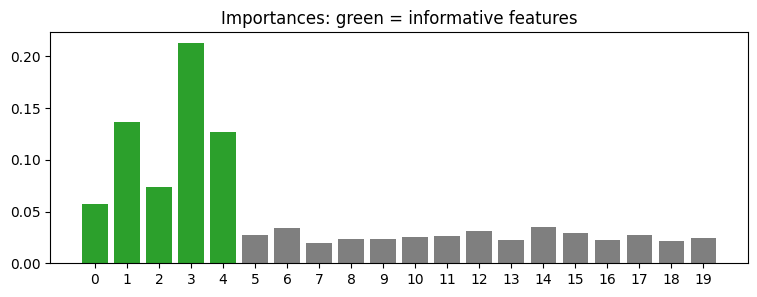

✅ informative features hold most of the importance  (0.6064 ≥ 0.6)
✅ top-5 importances are the informative features


True

In [7]:
X_inf, y_inf = datasets.make_classification(n_samples=800, n_features=20, n_informative=5, n_redundant=0,
                                            shuffle=False, random_state=SEED)
m = RandomForest(n_estimators=60, max_depth=8, random_state=SEED).fit(X_inf, y_inf)
imp = m.feature_importances_
plt.figure(figsize=(9, 3))
plt.bar(range(20), imp, color=["tab:green"] * 5 + ["tab:gray"] * 15)
plt.title("Importances: green = informative features"); plt.xticks(range(20)); plt.show()
checks.at_least("informative features hold most of the importance", imp[:5].sum(), 0.6)
checks.check("top-5 importances are the informative features", set(np.argsort(imp)[-5:]) == set(range(5)))

## 6. Real data (online): Spambase

4 601 emails described by 57 word and character frequencies, labelled spam or not spam. Random forests usually reach about 95 % here.

In [8]:
def _spambase():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=94)
    return d.data.features.to_numpy(float), d.data.targets.to_numpy().ravel().astype(int)

spam, online = load_online("Spambase (UCI 94)", _spambase)
if online:
    Xs, ys = spam
    Xa, Xb, ya, yb = train_test_split(Xs, ys, test_size=0.25, random_state=SEED, stratify=ys)
    with timed("our forest on 3 450 emails (50 trees)"):
        sm = RandomForest(n_estimators=50, max_depth=12, oob_score=True, random_state=SEED).fit(Xa, ya)
    a = acc(sm, Xb, yb)
    print(f"Spambase test accuracy {a:.4f} | OOB {sm.oob_score_:.4f}")
    checks.at_least("Spambase: test accuracy", a, 0.92)
    checks.at_most("Spambase: OOB ≈ test", abs(sm.oob_score_ - a), 0.03)
else:
    checks.skip("Spambase checks", "dataset unavailable offline")

🌐 Spambase (UCI 94): downloaded / loaded from cache


⏱️ our forest on 3 450 emails (50 trees): 2.81s
Spambase test accuracy 0.9435 | OOB 0.9409
✅ Spambase: test accuracy  (0.9435 ≥ 0.92)
✅ Spambase: OOB ≈ test  (0.0027 ≤ 0.03)


## Summary

In [9]:
checks.summary()

04 random forest: 24 passed, 0 failed, 0 skipped, 0 known bug(s) (24 checks)


,check,status,detail
0,fit() returns self,pass,
1,trees_ has n_estimators trees,pass,
2,classes_ are the sorted labels,pass,
3,every tree respects max_depth,pass,
4,same random_state → identical predictions,pass,
5,trees differ from each other (bootstrap + feat...,pass,
6,predict() is the majority vote of the trees,pass,
7,feature_importances_ sum to 1,pass,max |Δ| = 0.00e+00
8,feature_importances_ = mean of the trees' impo...,pass,max |Δ| = 0.00e+00
9,bagging off + all features == single tree,pass,
